# Predicting Parkinson's disease using Machine Learning

In [4]:
# Import all the tools we need

# Regular EDA(Exploratory data analysis) and plotting libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

#We want our plots to appear inside the notebook
%matplotlib inline 

# Models from Scikit-Learn
from sklearn.linear_model import LogisticRegression
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier

# Model Evaluations
from sklearn.model_selection import train_test_split,cross_val_score
from sklearn.model_selection import RandomizedSearchCV,GridSearchCV
from sklearn.metrics import confusion_matrix, classification_report

#Ignoring the warnings
import warnings
warnings.filterwarnings("ignore")

#Pandas-Profiling helps to build a widget that can be used to better visualise it
# Importing libraries
import numpy as np
import pandas as pd
from scipy.stats import mode
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.svm import SVC
from sklearn.naive_bayes import GaussianNB
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix
 
%matplotlib inline

name - ASCII subject name and recording number

MDVP:Fo(Hz) - Average vocal fundamental frequency
    
MDVP:Fhi(Hz) - Maximum vocal fundamental frequency
    
MDVP:Flo(Hz) - Minimum vocal fundamental frequency
    
MDVP:Jitter(%),MDVP:Jitter(Abs),MDVP:RAP,MDVP:PPQ,Jitter:DDP - Several
measures of variation in fundamental frequency

MDVP:Shimmer,MDVP:Shimmer(dB),Shimmer:APQ3,Shimmer:APQ5,MDVP:APQ,Shimmer:DDA - Several measures of variation in amplitude
NHR,HNR - Two measures of ratio of noise to tonal components in the voice

status - Health status of the subject (one) - Parkinson's, (zero) - healthy

RPDE,D2 - Two nonlinear dynamical complexity measures

DFA - Signal fractal scaling exponent

spread1,spread2,PPE - Three nonlinear measures of fundamental frequency variation

### Importing the dataset

In [5]:
df=pd.read_csv('parkinsons.csv')

### Shape of the dataset (Rows, Columns)

In [6]:
df.shape

(195, 24)

### Head of the dataset

In [7]:
df.head()

,name,MDVP:Fo(Hz),MDVP:Fhi(Hz),MDVP:Flo(Hz),MDVP:Jitter(%),MDVP:Jitter(Abs),MDVP:RAP,MDVP:PPQ,Jitter:DDP,MDVP:Shimmer,...,Shimmer:DDA,NHR,HNR,status,RPDE,DFA,spread1,spread2,D2,PPE
0,phon_R01_S01_1,119.992,157.302,74.997,0.00784,0.00007,0.00370,0.00554,0.01109,0.04374,...,0.06545,0.02211,21.033,1,0.414783,0.815285,-4.813031,0.266482,2.301442,0.284654
1,phon_R01_S01_2,122.400,148.650,113.819,0.00968,0.00008,0.00465,0.00696,0.01394,0.06134,...,0.09403,0.01929,19.085,1,0.458359,0.819521,-4.075192,0.335590,2.486855,0.368674
2,phon_R01_S01_3,116.682,131.111,111.555,0.01050,0.00009,0.00544,0.00781,0.01633,0.05233,...,0.08270,0.01309,20.651,1,0.429895,0.825288,-4.443179,0.311173,2.342259,0.332634
3,phon_R01_S01_4,116.676,137.871,111.366,0.00997,0.00009,0.00502,0.00698,0.01505,0.05492,...,0.08771,0.01353,20.644,1,0.434969,0.819235,-4.117501,0.334147,2.405554,0.368975
4,phon_R01_S01_5,116.014,141.781,110.655,0.01284,0.00011,0.00655,0.00908,0.01966,0.06425,...,0.10470,0.01767,19.649,1,0.417356,0.823484,-3.747787,0.234513,2.332180,0.410335


<br><br>
# Exploratory Data analysis
<br>

### Renaming columns

In [8]:
df.rename(columns ={'MDVP:Fo(Hz)':'Average vocal fundamental frequency',
                    'MDVP:Fhi(Hz)':'Maximum vocal fundamental frequency',
                    'MDVP:Flo(Hz)':' Minimum vocal fundamental frequency',
                    'MDVP:Jitter(%)':'Jitter(%)','MDVP:Jitter(Abs)':'Jitter(Abs)',
                    'fbs':'Fasting_blood_sugar',
                    'restecg':'ECG_results','thalach':'Maximum_heart_rate',
                    'exang':'Exercise_induced_angina','oldpeak':'ST_depression',
                    'slope':'ST_slope','ca':'Major_vessels',
                   'thal':'Thalassemia_types','target':'Heart_disease'}, inplace = True)

In [9]:
# View of the Renamed Dataframe
df.head()

,name,Average vocal fundamental frequency,Maximum vocal fundamental frequency,Minimum vocal fundamental frequency,Jitter(%),Jitter(Abs),MDVP:RAP,MDVP:PPQ,Jitter:DDP,MDVP:Shimmer,...,Shimmer:DDA,NHR,HNR,status,RPDE,DFA,spread1,spread2,D2,PPE
0,phon_R01_S01_1,119.992,157.302,74.997,0.00784,0.00007,0.00370,0.00554,0.01109,0.04374,...,0.06545,0.02211,21.033,1,0.414783,0.815285,-4.813031,0.266482,2.301442,0.284654
1,phon_R01_S01_2,122.400,148.650,113.819,0.00968,0.00008,0.00465,0.00696,0.01394,0.06134,...,0.09403,0.01929,19.085,1,0.458359,0.819521,-4.075192,0.335590,2.486855,0.368674
2,phon_R01_S01_3,116.682,131.111,111.555,0.01050,0.00009,0.00544,0.00781,0.01633,0.05233,...,0.08270,0.01309,20.651,1,0.429895,0.825288,-4.443179,0.311173,2.342259,0.332634
3,phon_R01_S01_4,116.676,137.871,111.366,0.00997,0.00009,0.00502,0.00698,0.01505,0.05492,...,0.08771,0.01353,20.644,1,0.434969,0.819235,-4.117501,0.334147,2.405554,0.368975
4,phon_R01_S01_5,116.014,141.781,110.655,0.01284,0.00011,0.00655,0.00908,0.01966,0.06425,...,0.10470,0.01767,19.649,1,0.417356,0.823484,-3.747787,0.234513,2.332180,0.410335


In [10]:
list (df.columns.values)


['name',
 'Average vocal fundamental frequency',
 'Maximum vocal fundamental frequency',
 ' Minimum vocal fundamental frequency',
 'Jitter(%)',
 'Jitter(Abs)',
 'MDVP:RAP',
 'MDVP:PPQ',
 'Jitter:DDP',
 'MDVP:Shimmer',
 'MDVP:Shimmer(dB)',
 'Shimmer:APQ3',
 'Shimmer:APQ5',
 'MDVP:APQ',
 'Shimmer:DDA',
 'NHR',
 'HNR',
 'status',
 'RPDE',
 'DFA',
 'spread1',
 'spread2',
 'D2',
 'PPE']

### Information about the data

In [11]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 195 entries, 0 to 194
Data columns (total 24 columns):
 #   Column                                Non-Null Count  Dtype  
---  ------                                --------------  -----  
 0   name                                  195 non-null    object 
 1   Average vocal fundamental frequency   195 non-null    float64
 2   Maximum vocal fundamental frequency   195 non-null    float64
 3    Minimum vocal fundamental frequency  195 non-null    float64
 4   Jitter(%)                             195 non-null    float64
 5   Jitter(Abs)                           195 non-null    float64
 6   MDVP:RAP                              195 non-null    float64
 7   MDVP:PPQ                              195 non-null    float64
 8   Jitter:DDP                            195 non-null    float64
 9   MDVP:Shimmer                          195 non-null    float64
 10  MDVP:Shimmer(dB)                      195 non-null    float64
 11  Shimmer:APQ3       

### Description about the dataset

In [12]:
df.describe()

,Average vocal fundamental frequency,Maximum vocal fundamental frequency,Minimum vocal fundamental frequency,Jitter(%),Jitter(Abs),MDVP:RAP,MDVP:PPQ,Jitter:DDP,MDVP:Shimmer,MDVP:Shimmer(dB),...,Shimmer:DDA,NHR,HNR,status,RPDE,DFA,spread1,spread2,D2,PPE
count,195.000000,195.000000,195.000000,195.000000,195.000000,195.000000,195.000000,195.000000,195.000000,195.000000,...,195.000000,195.000000,195.000000,195.000000,195.000000,195.000000,195.000000,195.000000,195.000000,195.000000
mean,154.228641,197.104918,116.324631,0.006220,0.000044,0.003306,0.003446,0.009920,0.029709,0.282251,...,0.046993,0.024847,21.885974,0.753846,0.498536,0.718099,-5.684397,0.226510,2.381826,0.206552
std,41.390065,91.491548,43.521413,0.004848,0.000035,0.002968,0.002759,0.008903,0.018857,0.194877,...,0.030459,0.040418,4.425764,0.431878,0.103942,0.055336,1.090208,0.083406,0.382799,0.090119
min,88.333000,102.145000,65.476000,0.001680,0.000007,0.000680,0.000920,0.002040,0.009540,0.085000,...,0.013640,0.000650,8.441000,0.000000,0.256570,0.574282,-7.964984,0.006274,1.423287,0.044539
25%,117.572000,134.862500,84.291000,0.003460,0.000020,0.001660,0.001860,0.004985,0.016505,0.148500,...,0.024735,0.005925,19.198000,1.000000,0.421306,0.674758,-6.450096,0.174351,2.099125,0.137451
50%,148.790000,175.829000,104.315000,0.004940,0.000030,0.002500,0.002690,0.007490,0.022970,0.221000,...,0.038360,0.011660,22.085000,1.000000,0.495954,0.722254,-5.720868,0.218885,2.361532,0.194052
75%,182.769000,224.205500,140.018500,0.007365,0.000060,0.003835,0.003955,0.011505,0.037885,0.350000,...,0.060795,0.025640,25.075500,1.000000,0.587562,0.761881,-5.046192,0.279234,2.636456,0.252980
max,260.105000,592.030000,239.170000,0.033160,0.000260,0.021440,0.019580,0.064330,0.119080,1.302000,...,0.169420,0.314820,33.047000,1.000000,0.685151,0.825288,-2.434031,0.450493,3.671155,0.527367


### Are there any missing values?

In [13]:
df.isna().sum() 

name                                    0
Average vocal fundamental frequency     0
Maximum vocal fundamental frequency     0
 Minimum vocal fundamental frequency    0
Jitter(%)                               0
Jitter(Abs)                             0
MDVP:RAP                                0
MDVP:PPQ                                0
Jitter:DDP                              0
MDVP:Shimmer                            0
MDVP:Shimmer(dB)                        0
Shimmer:APQ3                            0
Shimmer:APQ5                            0
MDVP:APQ                                0
Shimmer:DDA                             0
NHR                                     0
HNR                                     0
status                                  0
RPDE                                    0
DFA                                     0
spread1                                 0
spread2                                 0
D2                                      0
PPE                               

### Correlation matrix & Matrix Visualisation

In [15]:
df = df.drop(columns='name',axis=1)
df.head()

,Average vocal fundamental frequency,Maximum vocal fundamental frequency,Minimum vocal fundamental frequency,Jitter(%),Jitter(Abs),MDVP:RAP,MDVP:PPQ,Jitter:DDP,MDVP:Shimmer,MDVP:Shimmer(dB),...,Shimmer:DDA,NHR,HNR,status,RPDE,DFA,spread1,spread2,D2,PPE
0,119.992,157.302,74.997,0.00784,0.00007,0.00370,0.00554,0.01109,0.04374,0.426,...,0.06545,0.02211,21.033,1,0.414783,0.815285,-4.813031,0.266482,2.301442,0.284654
1,122.400,148.650,113.819,0.00968,0.00008,0.00465,0.00696,0.01394,0.06134,0.626,...,0.09403,0.01929,19.085,1,0.458359,0.819521,-4.075192,0.335590,2.486855,0.368674
2,116.682,131.111,111.555,0.01050,0.00009,0.00544,0.00781,0.01633,0.05233,0.482,...,0.08270,0.01309,20.651,1,0.429895,0.825288,-4.443179,0.311173,2.342259,0.332634
3,116.676,137.871,111.366,0.00997,0.00009,0.00502,0.00698,0.01505,0.05492,0.517,...,0.08771,0.01353,20.644,1,0.434969,0.819235,-4.117501,0.334147,2.405554,0.368975
4,116.014,141.781,110.655,0.01284,0.00011,0.00655,0.00908,0.01966,0.06425,0.584,...,0.10470,0.01767,19.649,1,0.417356,0.823484,-3.747787,0.234513,2.332180,0.410335


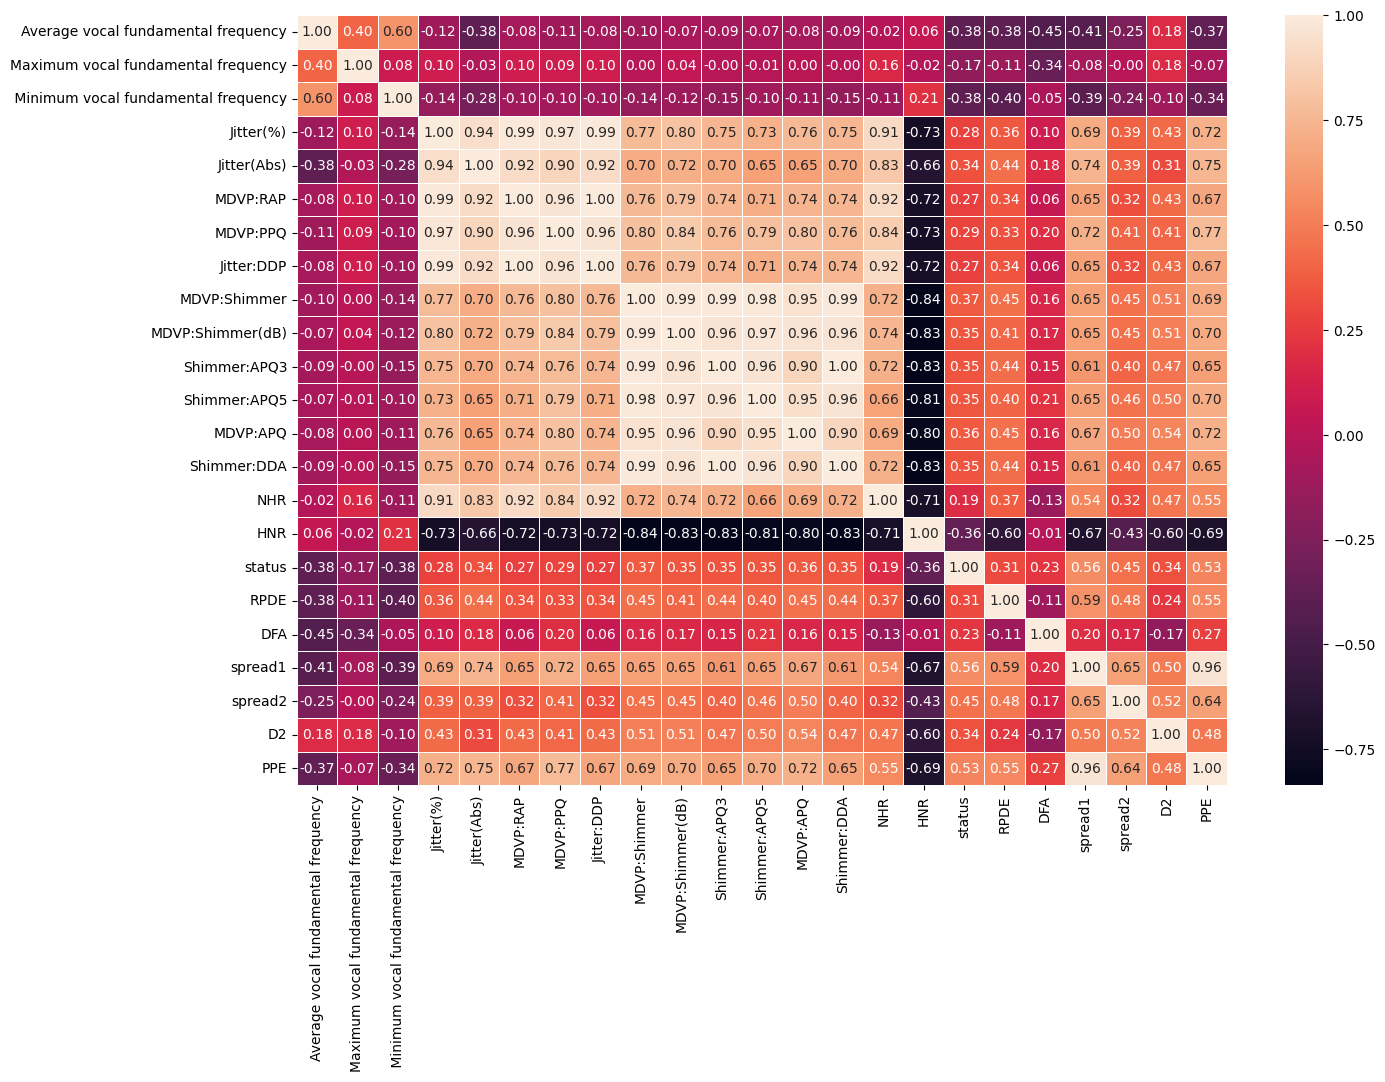

In [16]:
# Let's make our correlation matrix visual
corr_matrix=df.corr()
fig,ax=plt.subplots(figsize=(15,10))
ax=sns.heatmap(corr_matrix,
               annot=True,
               linewidths=0.5,
               fmt=".2f"
              )

## 3. Random Forest

In [18]:
X=df.drop(['status'],axis=1)
y=df['status']
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42)

lr=LogisticRegression()
lr.fit(X_train,y_train)
lr.score(X_train,y_train)
lr.score(X_test,y_test)



rf=RandomForestClassifier()


In [19]:
rf.fit(X_train,y_train)

RandomForestClassifier()

In [20]:
#Training score

rf.score(X_train,y_train)

1.0

In [21]:
#Prediction of the test variable

rf_y_preds=rf.predict(X_test)

In [22]:
#Testing accuracy

rf.score(X_test,y_test)

0.9230769230769231

### Classification Report

In [23]:
print(classification_report(y_test,rf_y_preds))

              precision    recall  f1-score   support

           0       0.83      0.71      0.77         7
           1       0.94      0.97      0.95        32

    accuracy                           0.92        39
   macro avg       0.89      0.84      0.86        39
weighted avg       0.92      0.92      0.92        39



In [24]:
svm = SVC()

In [25]:
svm.fit(X_train,y_train)

SVC()

In [26]:
svm.score(X_train,y_train)

0.8076923076923077

In [27]:
preds=svm.predict(X_test)
svm.score(X_test,y_test)




knn=KNeighborsClassifier()
knn.fit(X_train,y_train)

knn.score(X_train,y_train)
knn.score(X_test,y_test)

0.8205128205128205

<br><br>
### Different Model Scores (accuracy)

In [28]:
model_scores={'Logistic Regression':lr.score(X_test,y_test),
             'KNN':knn.score(X_test,y_test),
             'Random Forest':rf.score(X_test,y_test),
             'svm':svm.score(X_test,y_test)}

In [29]:
model_scores

{'Logistic Regression': 0.8974358974358975,
 'KNN': 0.8205128205128205,
 'Random Forest': 0.9230769230769231,
 'svm': 0.8461538461538461}

## Model Comparison

In [30]:
#Based on accuracy
model_compare=pd.DataFrame(model_scores,index=['status'])
model_compare

,Logistic Regression,KNN,Random Forest,svm
status,0.897436,0.820513,0.923077,0.846154


In [31]:
import pickle
filename = 'parkinsons.sav'
pickle.dump(rf, open(filename, 'wb'))
  

<Axes: >

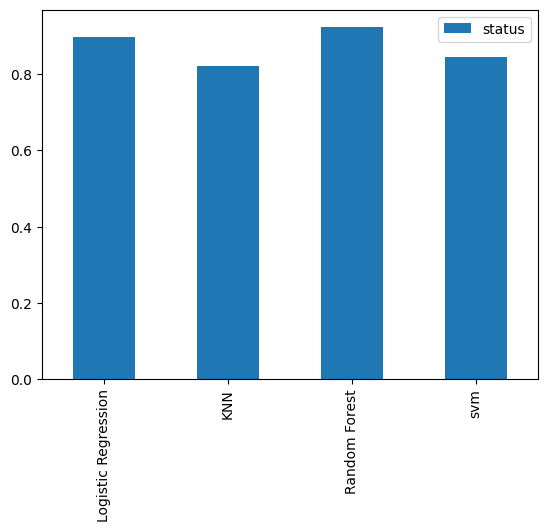

In [32]:
model_compare.T.plot(kind='bar') # (T is here for transpose)

In [35]:
import pickle
pickle.dump(rf,open('parkinson.pkl','wb'))